# Notebook status and evaluation note

This notebook is retained as a portfolio record of the original experiment. The workflow evaluates `test_loader` during training and uses test accuracy for checkpoint selection. Its stored metrics are therefore **historical development results**, not a final estimate from an untouched test set. A rigorous rerun should select checkpoints on a separate validation split and evaluate the test split once.

The original Google Colab and Google Drive paths are also retained and must be changed before running the notebook.


In [ ]:
import os
import random
import math
import shutil

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [ ]:
# ==============================================================
# 3. Mount Google Drive & Load Dataset
# ==============================================================
from google.colab import drive
import zipfile

drive.mount('/content/drive')

zip_path     = "/content/drive/MyDrive/chest_xray.zip"
extract_path = "/content/MyDrive/chest_xray"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
print("Dataset ready at:", extract_path)

Mounted at /content/drive
Dataset ready at: /content/MyDrive/chest_xray


In [ ]:
# 4. Merge train + test + val → Balance → 80-20 Split
# ==============================================================
set_seed(42)

base = extract_path
if os.path.isdir(os.path.join(base, "chest_xray")):
    base = os.path.join(base, "chest_xray")

def find_class_dir(parent, class_name):
    for d in os.listdir(parent):
        if d.lower() == class_name.lower():
            return os.path.join(parent, d)
    raise FileNotFoundError(f"{class_name} not found in {parent}")

normal_dirs    = []
pneumonia_dirs = []

for split in ["train", "test", "val"]:
    split_path = os.path.join(base, split)
    normal_dirs.append(find_class_dir(split_path, "normal"))
    pneumonia_dirs.append(find_class_dir(split_path, "pneumonia"))

normal_imgs    = []
for d in normal_dirs:
    normal_imgs += [os.path.join(d, f) for f in os.listdir(d)]

pneumonia_imgs = []
for d in pneumonia_dirs:
    pneumonia_imgs += [os.path.join(d, f) for f in os.listdir(d)]

print("Original counts → Normal:", len(normal_imgs),
      "Pneumonia:", len(pneumonia_imgs))

# Balance
pneumonia_imgs = random.sample(pneumonia_imgs, len(normal_imgs))

# Split
norm_train, norm_test = train_test_split(
    normal_imgs, test_size=0.2, random_state=42)
pneu_train, pneu_test = train_test_split(
    pneumonia_imgs, test_size=0.2, random_state=42)

# Output folders
balanced_base = "/content/balanced_chest_xray"
train_dir     = f"{balanced_base}/train"
test_dir      = f"{balanced_base}/test"

for cls in ["NORMAL", "PNEUMONIA"]:
    os.makedirs(f"{train_dir}/{cls}", exist_ok=True)
    os.makedirs(f"{test_dir}/{cls}",  exist_ok=True)

def copy_files(files, dst):
    for f in files:
        shutil.copy(f, dst)

copy_files(norm_train, f"{train_dir}/NORMAL")
copy_files(norm_test,  f"{test_dir}/NORMAL")
copy_files(pneu_train, f"{train_dir}/PNEUMONIA")
copy_files(pneu_test,  f"{test_dir}/PNEUMONIA")

print("Balanced dataset created")
print("Train → Normal:", len(norm_train), " Pneumonia:", len(pneu_train))
print("Test  → Normal:", len(norm_test),  " Pneumonia:", len(pneu_test))


Original counts → Normal: 1583 Pneumonia: 4273
Balanced dataset created
Train → Normal: 1266  Pneumonia: 1266
Test  → Normal: 317  Pneumonia: 317


In [ ]:
# 5. Load Images into Memory
# ==============================================================
img_size = (224, 224)

def load_images_from_folder(folder, label, target_size=img_size):
    data, labels = [], []
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path).convert("RGB").resize(target_size)
            data.append(np.array(img))
            labels.append(label)
        except:
            pass
    return data, labels

train_norm, y1  = load_images_from_folder(f"{train_dir}/NORMAL",    0)
train_pneu, y2  = load_images_from_folder(f"{train_dir}/PNEUMONIA", 1)
test_norm,  y1t = load_images_from_folder(f"{test_dir}/NORMAL",     0)
test_pneu,  y2t = load_images_from_folder(f"{test_dir}/PNEUMONIA",  1)

X_train = np.array(train_norm + train_pneu)
y_train = np.array(y1 + y2)
X_test  = np.array(test_norm  + test_pneu)
y_test  = np.array(y1t + y2t)

print("Train:", X_train.shape, " Test:", X_test.shape)

# Sanity check
assert Counter(y_train)[0] == Counter(y_train)[1], "Train set NOT balanced!"
assert Counter(y_test)[0]  == Counter(y_test)[1],  "Test set NOT balanced!"
print("Sanity check passed: datasets are balanced")

Train: (2532, 224, 224, 3)  Test: (634, 224, 224, 3)
Sanity check passed: datasets are balanced


In [ ]:
# 5.1 Dataset Class & DataLoaders
# ==============================================================
class ImageDataset(Dataset):
    def __init__(self, X, y, train=True):
        self.X = X
        self.y = y
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0))
                if train else transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip()
                if train else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img   = self.X[idx]
        label = self.y[idx]
        img   = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(
    ImageDataset(X_train, y_train, train=True),
    batch_size=16, shuffle=True
)
test_loader = DataLoader(
    ImageDataset(X_test, y_test, train=False),
    batch_size=16, shuffle=False
)

In [ ]:
# 6. Model Definition — Pure ResNet-18
# ==============================================================
class BaselineResNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.model = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT)
        in_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(in_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

In [ ]:
# 7. Training Helper — plots loss & accuracy curves
# ==============================================================
def plot_training(history, title="Baseline ResNet"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], "g-o", label="Train Acc")
    axes[1].plot(epochs, history["test_acc"],  "m-o", label="Test Acc")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    diff = [t - tr for t, tr
            in zip(history["test_acc"], history["train_acc"])]
    axes[2].plot(epochs, diff, "k-o")
    axes[2].axhline(0, color="red", linestyle="--")
    axes[2].set_title("Test Acc − Train Acc")
    axes[2].set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

In [ ]:
# 8. Train Model
#    Phase 1 — Warmup  (3 epochs, backbone frozen)
#    Phase 2 — Full    (15 epochs, all layers unfrozen)
# ==============================================================
def train_model(model, train_loader, test_loader, device,
                epochs=15, warmup_epochs=3,
                save_path="best_baseline_resnet.pth"):

    model.to(device)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0
    history   = {"train_loss": [], "train_acc": [], "test_acc": []}

    # ── Phase 1: Warmup — freeze backbone, train fc only ────────
    print(f"Warm-up for {warmup_epochs} epochs...")
    for name, param in model.named_parameters():
        param.requires_grad = ("fc" in name)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3
    )

    for epoch in range(warmup_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for imgs, labels in tqdm(train_loader,
                                 desc=f"Warmup {epoch+1}/{warmup_epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, predicted  = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

        train_acc = 100 * correct / total

        model.eval()
        t_correct, t_total = 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs      = model(imgs)
                _, predicted = torch.max(outputs, 1)
                t_correct += (predicted == labels).sum().item()
                t_total   += labels.size(0)
        test_acc = 100 * t_correct / t_total

        print(f"Warmup Epoch {epoch+1}: "
              f"Loss={running_loss/total:.4f}  "
              f"Acc={train_acc:.2f}%  TestAcc={test_acc:.2f}%")

    # ── Phase 2: Full training — unfreeze everything ─────────────
    print("\nFull Training...")
    for param in model.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=5, gamma=0.5)

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for imgs, labels in tqdm(train_loader,
                                 desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, predicted  = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

        train_acc = 100 * correct / total

        model.eval()
        t_correct, t_total = 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs      = model(imgs)
                _, predicted = torch.max(outputs, 1)
                t_correct += (predicted == labels).sum().item()
                t_total   += labels.size(0)
        test_acc = 100 * t_correct / t_total

        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), save_path)
            print(f"  Saved best model ({best_acc:.2f}%)")

        print(f"Epoch {epoch+1}/{epochs}:  "
              f"Loss={running_loss/total:.4f}  "
              f"TrainAcc={train_acc:.2f}%  "
              f"TestAcc={test_acc:.2f}%")

        scheduler.step()

    return history, best_acc

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]


Warm-up for 3 epochs...


Warmup 1/3: 100%|██████████| 159/159 [03:59<00:00,  1.51s/it]


Warmup Epoch 1: Loss=0.4127  Acc=81.20%  TestAcc=91.48%


...

Epoch 13/15:  Loss=0.0201  TrainAcc=99.68%  TestAcc=97.48%


Epoch 14/15: 100%|██████████| 159/159 [10:34<00:00,  3.99s/it]


Epoch 14/15:  Loss=0.0202  TrainAcc=99.21%  TestAcc=96.53%


Epoch 15/15: 100%|██████████| 159/159 [10:30<00:00,  3.97s/it]


Epoch 15/15:  Loss=0.0114  TrainAcc=99.76%  TestAcc=96.37%


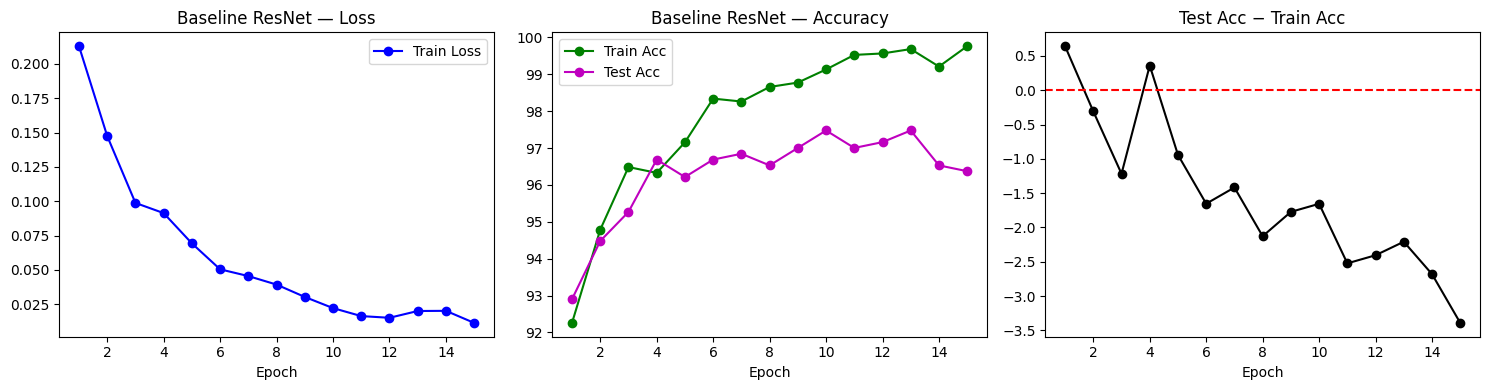


Baseline ResNet — Best Test Accuracy: 97.48%


In [ ]:
# 9. Run Training
# ==============================================================
baseline_path = "/content/drive/MyDrive/best_baseline_resnet.pth"

b_model = BaselineResNet(num_classes=2).to(device)

b_hist, b_acc = train_model(
    b_model,
    train_loader,
    test_loader,
    device,
    epochs=15,
    warmup_epochs=3,
    save_path=baseline_path
)

plot_training(b_hist, title="Baseline ResNet")
print(f"\nBaseline ResNet — Best Test Accuracy: {b_acc:.2f}%")


In [ ]:
b_model.load_state_dict(torch.load(baseline_path))
b_model.eval()

BaselineResNet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

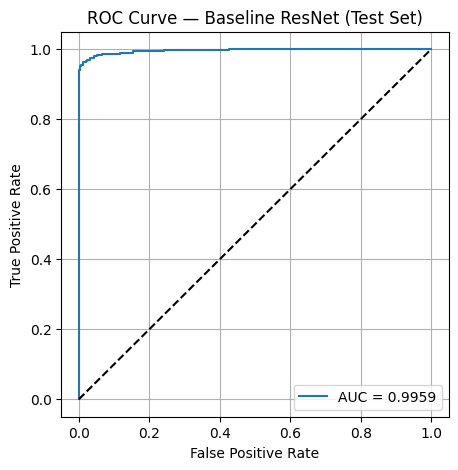

ROC AUC: 0.9959199514374708


In [ ]:


# ==============================================================
# 11. ROC Curve
# ==============================================================
def plot_roc_curve(model, dataloader, device, title="Baseline ResNet"):
    model.eval()
    y_true, y_score = [], []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs    = imgs.to(device)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            y_score.extend(probs)
            y_true.extend(labels.numpy())

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {title} (Test Set)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    print("ROC AUC:", roc_auc)
    return roc_auc

b_auc = plot_roc_curve(b_model, test_loader, device)


<Figure size 600x600 with 0 Axes>

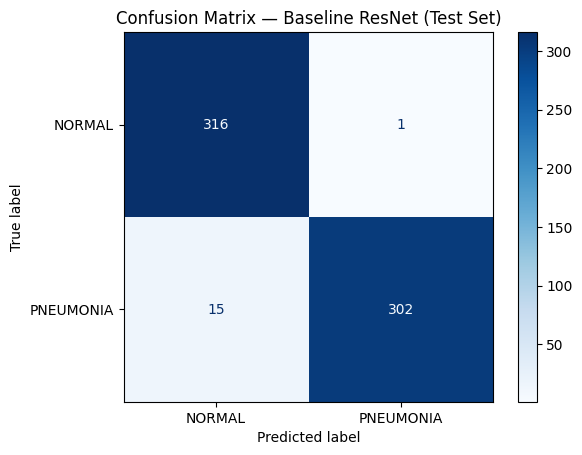


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      1.00      0.98       317
   PNEUMONIA       1.00      0.95      0.97       317

    accuracy                           0.97       634
   macro avg       0.98      0.97      0.97       634
weighted avg       0.98      0.97      0.97       634


Model                          Best Acc   ROC AUC
--------------------------------------------------
Baseline ResNet-18               97.48%    0.9959
Quantum Hybrid ResNet            98.11%    0.9916


In [ ]:
# 12. Confusion Matrix + Classification Report
# ==============================================================
def plot_confusion_matrix(model, dataloader, device, title="Baseline ResNet"):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs    = imgs.to(device)
            outputs = model(imgs)
            preds   = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["NORMAL", "PNEUMONIA"]
    )
    plt.figure(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix — {title} (Test Set)")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    ))

plot_confusion_matrix(b_model, test_loader, device)


# ==============================================================
# 13. Final Summary
#     Compare numbers against your Quantum Hybrid results
#     manually — paste those values in the variables below
# ==============================================================

quantum_best_acc = 98.11   # ← your quantum hybrid best test acc
quantum_auc      = 0.9916  # ← your quantum hybrid ROC AUC

print("\n" + "=" * 50)
print(f"{'Model':<28} {'Best Acc':>10}  {'ROC AUC':>8}")
print("-" * 50)
print(f"{'Baseline ResNet-18':<28} {b_acc:>9.2f}%  {b_auc:>8.4f}")
print(f"{'Quantum Hybrid ResNet':<28} {quantum_best_acc:>9.2f}%  {quantum_auc:>8.4f}")
print("=" * 50)